# Таксономический анализ

### Анализ парноконцевых чтений с помощью MetaPhlAn

In [ ]:
!apt-get update && apt-get install -y bowtie2

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,201 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,842 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis

In [ ]:
!pip install metaphlan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.1/465.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 95.8 MB/s eta 0:00:00


In [ ]:
!metaphlan --version

MetaPhlAn version 4.2.4 (21 Oct 2025)
No complete MetaPhlAn Bowtie2 database found


In [ ]:
# подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# удаление предыдущих map файлов (при повторном запуске)
import os
if os.path.exists('RCGS_99z.map'):
    print("Удаляю старый файл RCGS_99z.map...")
    os.remove('RCGS_99z.map')
    print("Файл удален")
else:
    print("Файл RCGS_99z.map не найден")

In [ ]:
# вариант 1 - Команда с --mapout для обработки нескольких файлов
print("Запуск MetaPhlAn 4 на полных ридах...")

!metaphlan \
    /content/drive/MyDrive/ВКР/метагеном/RCGS_99z_L001_R1.paired.fastq.gz,/content/drive/MyDrive/ВКР/метагеном/RCGS_99z_L001_R2.paired.fastq.gz \
    --input_type fastq \
    --nproc 2 \
    --mapout RCGS_99z.map \
    --tax_lev s \
    -o RCGS_99z_full_profile.txt 2>&1 | tee full_analysis.log

Запуск MetaPhlAn 4 на полных ридах...
Sun Dec  7 14:49:41 2025: Downloading http://cmprod1.cibio.unitn.it/biobakery4/metaphlan_databases/mpa_latest
Sun Dec  7 14:49:42 2025: Downloading file of size: 0.0000 MB
Sun Dec  7 14:49:42 2025: MetaPhlAn database not present or partially present in /usr/local/lib/python3.12/dist-packages/metaphlan/metaphlan_databases. 
 Please note due to the size this might take a few minutes.
Sun Dec  7 14:49:42 2025: Downloading and uncompressing bowtie2 indexes
Sun Dec  7 14:49:42 2025: Downloading http://cmprod1.cibio.unitn.it/biobakery4/metaphlan_databases/bowtie2_indexes/mpa_vJan25_CHOCOPhlAnSGB_202503_bt2.tar
Sun Dec  7 14:49:42 2025: Downloading file of size: 33433.5645 MB
Sun Dec  7 15:32:59 2025: Downloading http://cmprod1.cibio.unitn.it/biobakery4/metaphlan_databases/bowtie2_indexes/mpa_vJan25_CHOCOPhlAnSGB_202503_bt2.md5
Sun Dec  7 15:33:00 2025: Downloading file of size: 0.0001 MB
Sun Dec  7 15:33:00 2025: Checking md5 of /usr/local/lib/python3.12

In [ ]:
# запуск MetaPhlAn с детекцией штаммов
print("Запуск MetaPhlAn для детекции штаммов...")

!metaphlan \
    /content/drive/MyDrive/ВКР/метагеном/RCGS_99z_L001_R1.paired.fastq.gz,/content/drive/MyDrive/ВКР/метагеном/RCGS_99z_L001_R2.paired.fastq.gz \
    --input_type fastq \
    --nproc 2 \
    --mapout RCGS_99z.map \
    --tax_lev s \                           # Уровень вида + штаммы
    --stat_q 0.1 \                          # Статистика каждые 10%
    --read_min_len 75 \                     # Только риды ≥75bp
    --bt2_ps very-sensitive-local \         # Максимально чувствительный режим
    --minimap2_ps map-ont \                 # Для длинных ридов (если есть)
    --min_cu_len 2500 \                     # Более строгий порог для штаммов
    --avoid_disqm \                         # Избегать дисквалифицированных маркеров
    --stat \                                # Статистика базы данных
    --CAMI_format_output \                  # Стандартный формат CAMI
    --biom_format_output \                  # Дополнительно в формате BIOM
    --profile_vsc \                         # Видовая стратификация сообществ
    --vsc_breadth 0.1 \                     # Порог breadth для VSC
    --min_mapq_val 20                       # Минимальное качество выравнивания
    --ignore_markers 5                      # Игнорировать 5% худших маркеров
    --no_map                                # Если не нужны промежуточные файлы
    --ignore_eukaryotes                     # Только бактерии/археи
#    --long_reads                            # Для длинных ридов (Nanopore/PacBio)
    --split_reads                           # Разделять длинные риды
    --sample_id_key "RCGS_99z"              # Имя образца в выводе
    --biom_mdelim "|"                       # Разделитель в BIOM формате
    -o RCGS_99z_detailed_profile.txt

Запуск MetaPhlAn для детекции штаммов...
usage: metaphlan --input_type {fastq,fasta,mapout,sam} [--force]
                 [--db_dir METAPHLAN_DB] [-x INDEX] [--mapout FILE_NAME]
                 [--min_mapq_val MIN_MAPQ_VAL] [--no_map] [--tmp_dir]
                 [--bt2_ps BowTie2 presets] [--bowtie2_exe BOWTIE2_EXE]
                 [--bowtie2_build BOWTIE2_BUILD] [--tax_lev TAXONOMIC_LEVEL]
                 [--min_alignment_len] [--ignore_eukaryotes]
                 [--ignore_bacteria] [--ignore_archaea] [--ignore_ksgbs]
                 [--ignore_usgbs] [--stat_q] [--perc_nonzero]
                 [--ignore_markers IGNORE_MARKERS] [--avoid_disqm] [--stat]
                 [-t ANALYSIS TYPE] [--nreads NUMBER_OF_READS]
                 [--pres_th PRESENCE_THRESHOLD] [-o output file]
                 [--sample_id_key name] [--use_group_representative]
                 [--sample_id value] [-s sam_output_file]
                 [--CAMI_format_output] [--skip_unclassified_estimation]
  

In [ ]:
# сохранение результатов
from google.colab import files
files.download('RCGS_99z_full_profile.txt')
files.download('RCGS_99z.map')
files.download('full_analysis.log')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Анализ полученных результатов

In [ ]:
# чтение файла
with open('RCGS_99z_full_profile.txt', 'r') as f:
    lines = f.readlines()

# поиск строк с данными (не начинающиеся с #)
data_lines = []
for line in lines:
    line = line.strip()
    if line and not line.startswith('#'):
        data_lines.append(line)

print(f"Найдено строк с данными: {len(data_lines)}")
print("\nПервые 5 строк данных:")
for i in range(min(5, len(data_lines))):
    print(f"  {i+1}: {data_lines[i]}")

Чтение файла вручную...
Найдено строк с данными: 24

Первые 5 строк данных:
  1: UNCLASSIFIED	-1	10.592127
  2: k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Streptococcus|s__Streptococcus_thermophilus	2|1239|91061|186826|1300|1301|1308	47.839364
  3: k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis	2|1239|91061|186826|1300|1357|1358	25.578064
  4: k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Staphylococcaceae|g__Staphylococcus|s__Staphylococcus_equorum	2|1239|91061|1385|90964|1279|246432	6.591923
  5: k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum	2|1239|91061|186826|33958|2767842|1590	2.460679


In [ ]:
# парсинг данных
print("\nПарсинг данных...")

data = []
for line in data_lines:
    parts = line.split('\t')

    if len(parts) >= 3:
        taxon_path = parts[0].strip()
        taxon_id = parts[1].strip()

        # поиск числовых значений abundance
        abundance = None
        for part in parts[2:]:
            try:
                abundance = float(part.strip())
                break
            except:
                continue

        if abundance is not None:
            data.append({
                'taxon_path': taxon_path,
                'taxon_id': taxon_id,
                'abundance': abundance
            })

# проверка
print(f"Успешно распарсено строк: {len(data)}")
print("\nПервые 3 записи:")
for i, record in enumerate(data[:3]):
    print(f"  {i+1}. {record['taxon_path'][:50]}... - {record['abundance']}%")


Парсинг данных...
Успешно распарсено строк: 24

Первые 3 записи:
  1. UNCLASSIFIED... - 10.592127%
  2. k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacil... - 47.839364%
  3. k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacil... - 25.578064%


In [ ]:
# создание dataframe и проверка данных
import pandas as pd

df = pd.DataFrame(data)
print(f"Создан dataframe с {len(df)} строками")
print("\nВсе таксоны:")
for i, row in df.iterrows():
    print(f"{i+1:2d}. {row['abundance']:6.2f}% - {row['taxon_path']}")

Создан DataFrame с 24 строками

Все таксоны:
 1.  10.59% - UNCLASSIFIED
 2.  47.84% - k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Streptococcus|s__Streptococcus_thermophilus
 3.  25.58% - k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis
 4.   6.59% - k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Staphylococcaceae|g__Staphylococcus|s__Staphylococcus_equorum
 5.   2.46% - k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum
 6.   2.04% - k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Leuconostoc|s__Leuconostoc_mesenteroides
 7.   1.47% - k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Leuconostoc|s__Leuconostoc_falkenbergense
 8.   0.77% - k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lacticaseibacillus|s__Lact

In [ ]:
# cоздание таблицы
print("Создание таблицы для документов...")

# сортировка по abundance
df_sorted = df.sort_values('abundance', ascending=False).reset_index(drop=True)

# создание таблицы
table_data = []
for i, row in df_sorted.iterrows():
    # извлечение названия вида (последний уровень таксономии)
    taxon_path = row['taxon_path']
    if '|' in str(taxon_path):
        # последний элемент после |
        parts = str(taxon_path).split('|')
        species_part = parts[-1]
        if '__' in species_part:
            _, species_name = species_part.split('__', 1)
            species_name = species_name.replace('_', ' ')
        else:
            species_name = species_part
    else:
        species_name = taxon_path

    table_data.append({
        'Rank': i + 1,
        'Taxon': species_name,
        'Abundance (%)': f"{row['abundance']:.3f}",
        'Full Taxonomy': taxon_path[:80] + '...' if len(taxon_path) > 80 else taxon_path
    })

# создаем dataframe для таблицы
result_table = pd.DataFrame(table_data)

# сохранение в CSV
csv_filename = 'RCGS_99z_taxonomic_profile_table.csv'
result_table.to_csv(csv_filename, index=False, encoding='utf-8-sig')

# просмотр в консоли
print("\n" + "="*100)
print("ТАКСОНОМИЧЕСКИЙ ПРОФИЛЬ МЕТАГЕНОМА RCGS_99z")
print("="*100)
print(f"{'Rank':<5} {'Abundance (%)':<15} {'Taxon':<40} {'Taxonomy Preview':<40}")
print("-"*100)

for _, row in result_table.iterrows():
    print(f"{row['Rank']:<5} {row['Abundance (%)']:<15} {row['Taxon']:<40} {row['Full Taxonomy']:<40}")

print("="*100)
print(f"\n✅ Таблица сохранена в файл: '{csv_filename}'")
print("   Формат: UTF-8 с BOM")
print("   Колонки: Rank, Taxon, Abundance (%), Full Taxonomy")

Создание таблицы для документов...

ТАКСОНОМИЧЕСКИЙ ПРОФИЛЬ МЕТАГЕНОМА RCGS_99z
Rank  Abundance (%)   Taxon                                    Taxonomy Preview                        
----------------------------------------------------------------------------------------------------
1     47.839          Streptococcus thermophilus               k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__S...
2     25.578          Lactococcus lactis                       k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__L...
3     10.592          UNCLASSIFIED                             UNCLASSIFIED                            
4     6.592           Staphylococcus equorum                   k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Staphylococcaceae|g__Staph...
5     2.461           Lactiplantibacillus plantarum            k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__L...
6     2.036           L

Подготовка данных для визуализации всех таксонов...
Создание графика для 24 таксонов...


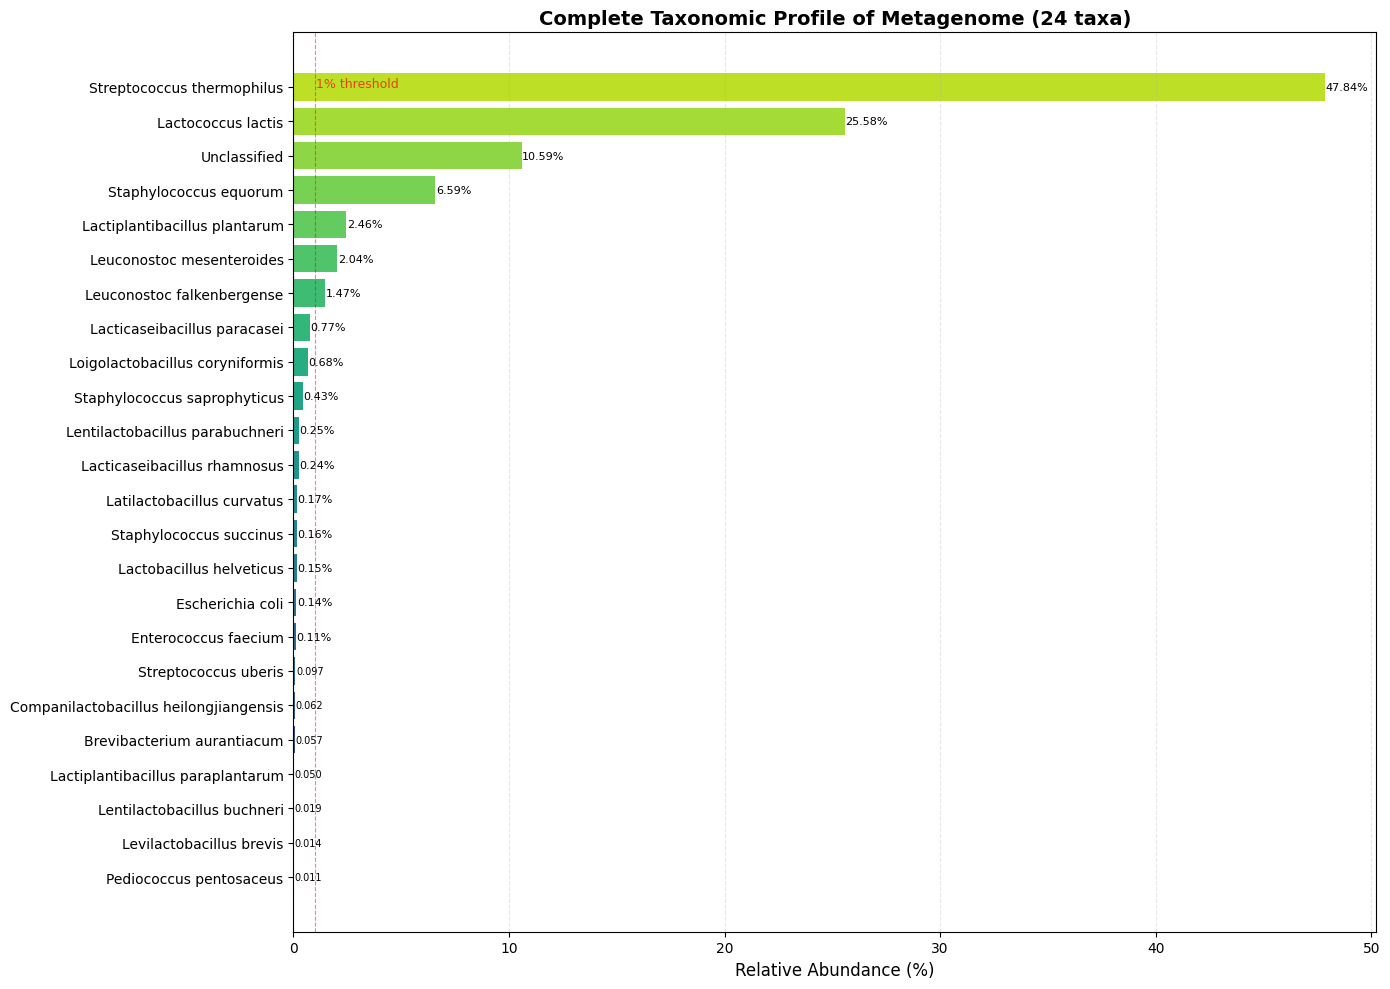


✅ График сохранен как: 'RCGS_99z_all_taxa.png'
   Показано таксонов: 24
   Красная линия: порог 1% abundance


In [ ]:
# визуализация всех найденных таксонов
import matplotlib.pyplot as plt
import numpy as np

print("Подготовка данных для визуализации всех таксонов...")

all_taxa = df_sorted.copy()

# функция для получения короткого имени
def get_short_name(taxon_path):
    if taxon_path == 'UNCLASSIFIED':
        return 'Unclassified'

    if '|' in str(taxon_path):
        parts = str(taxon_path).split('|')
        # поиск species (s__) или genus (g__)
        for part in reversed(parts):
            if '__' in part:
                prefix, name = part.split('__', 1)
                if prefix.startswith('s'):
                    return name.replace('_', ' ')
                elif prefix.startswith('g'):
                    return f"{name} spp."

        # если не найдены species/genus, берем последний
        last_part = parts[-1]
        if '__' in last_part:
            _, name = last_part.split('__', 1)
            return name.replace('_', ' ')

    return str(taxon_path)

# добавление коротких имен
all_taxa['short_name'] = all_taxa['taxon_path'].apply(get_short_name)

# создание графика
print(f"Создание графика для {len(all_taxa)} таксонов...")
plt.figure(figsize=(14, 10))

# горизонтальный барплот
bars = plt.barh(range(len(all_taxa)), all_taxa['abundance'][::-1],
                color=plt.cm.viridis(np.linspace(0.1, 0.9, len(all_taxa))))
plt.yticks(range(len(all_taxa)), all_taxa['short_name'][::-1])
plt.xlabel('Relative Abundance (%)', fontsize=12)
plt.title(f'Complete Taxonomic Profile of Metagenome RCGS_99z ({len(all_taxa)} taxa)',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# добавление значений на столбцы
for i, (bar, abundance) in enumerate(zip(bars, all_taxa['abundance'][::-1])):
    if abundance >= 0.1:  # Показываем для abundance >= 0.1%
        plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{abundance:.2f}%', ha='left', va='center', fontsize=8)
    elif abundance >= 0.01:  # для очень малых значений - компактнее
        plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{abundance:.3f}', ha='left', va='center', fontsize=7)

# добавление вертикальной линии для 1%
plt.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
plt.text(1.05, len(all_taxa)-1, '1% threshold', color='red', fontsize=9, alpha=0.7)

plt.tight_layout()

# сохранение графика
plot_filename = 'RCGS_99z_all_taxa.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ График сохранен как: '{plot_filename}'")
print(f"   Показано таксонов: {len(all_taxa)}")
print("   Красная линия: порог 1% abundance")

Создание круговой диаграммы топ-10 таксонов...


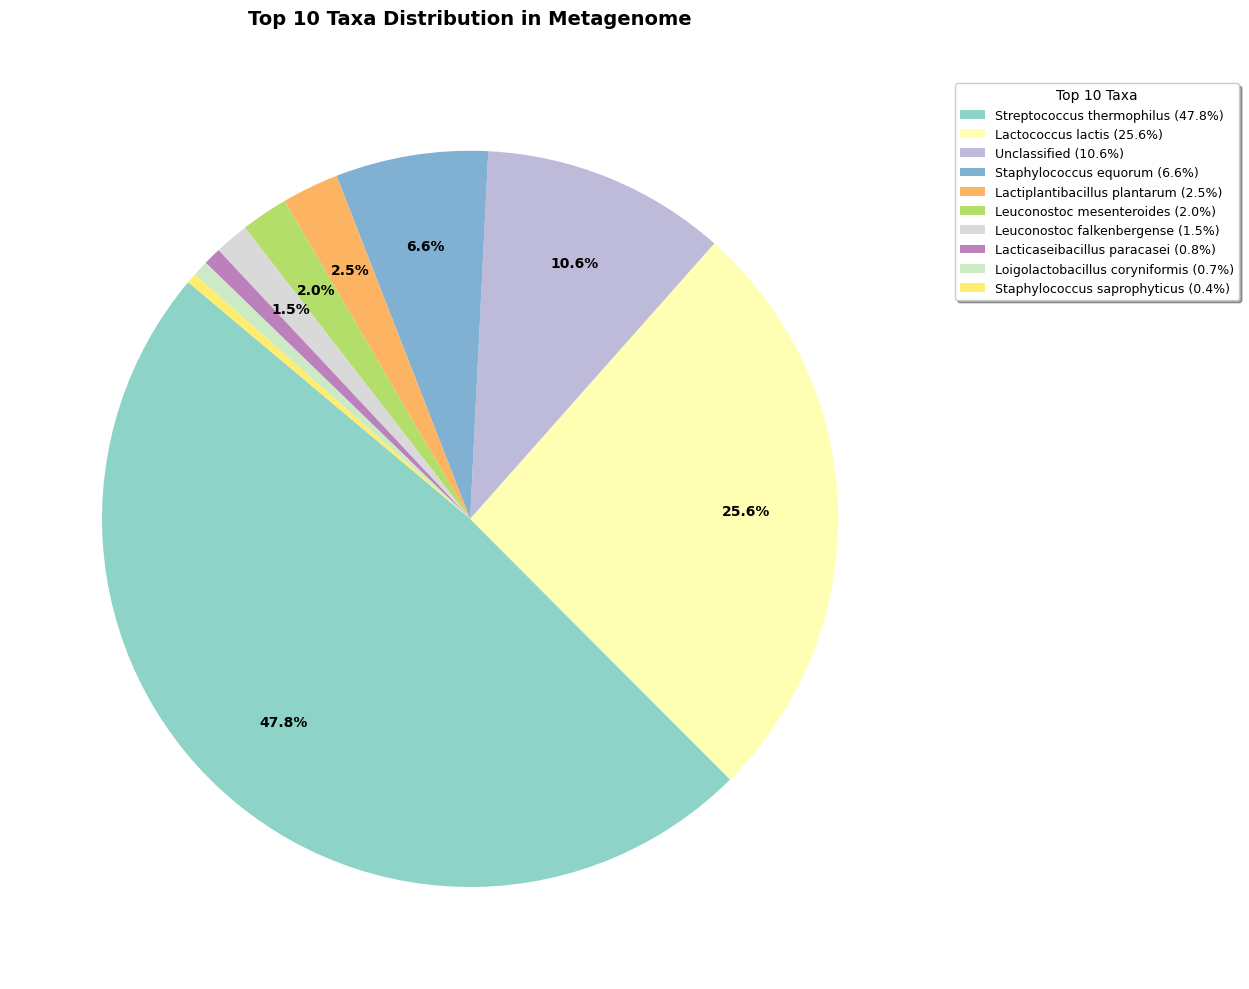


✅ Круговая диаграмма сохранена как: 'RCGS_99z_top10_pie.png'
   Показано: топ-10 таксонов


In [ ]:
# круговая диаграмма
print("Создание круговой диаграммы топ-10 таксонов...")

# берем топ-10
top10 = all_taxa.head(10).copy()

# размер изображения
plt.figure(figsize=(14, 10))

# круговая диаграмма
colors = plt.cm.Set3(np.linspace(0, 1, len(top10)))

# функция для подписей
def autopct_format(pct):
    total = sum(top10['abundance'])
    val = pct * total / 100.0
    return f'{val:.1f}%' if val > 1 else ''

# создание диаграммы
wedges, texts, autotexts = plt.pie(top10['abundance'],
                                   labels=None,
                                   colors=colors,
                                   autopct=autopct_format,
                                   startangle=140,
                                   textprops={'fontsize': 10, 'fontweight': 'bold'},
                                   pctdistance=0.75,
                                   labeldistance=None)

# процентные подписи
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

# добавление подписей в виде аннотаций
from matplotlib.patches import Patch

# создание легенды
legend_elements = []
for _, row in top10.iterrows():
    legend_elements.append(
        Patch(facecolor=colors[len(legend_elements)],
              label=f"{row['short_name']} ({row['abundance']:.1f}%)")
    )

# расположение легенды
plt.legend(handles=legend_elements,
           title="Top 10 Taxa",
           loc='upper left',
           bbox_to_anchor=(1.02, 0.98),
           fontsize=9,
           title_fontsize=10,
           frameon=True,
           fancybox=True,
           shadow=True)

# заголовок
plt.title('Top 10 Taxa Distribution in Metagenome',
          fontsize=14, fontweight='bold', pad=25)

# отступы для легенды
plt.tight_layout()
plt.subplots_adjust(right=0.75)  # Освобождаем место справа для легенды

# сохранение
pie_filename = 'RCGS_99z_top10_pie.png'
plt.savefig(pie_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Круговая диаграмма сохранена как: '{pie_filename}'")
print("   Показано: топ-10 таксонов")

Анализ распределения по таксономическим уровням (все таксоны)...

📊 PHYLUM LEVEL (всего: 4)
Taxon                                Abundance       %
-------------------------------------------------------
  Firmicutes                            89.212%
Unclassified                            10.592%
  Pseudomonadota                         0.138%
  Actinomycetota                         0.057%
-------------------------------------------------------
TOTAL                                   100.00%

📊 CLASS LEVEL (всего: 4)
Taxon                                Abundance       %
-------------------------------------------------------
  Bacilli                               89.212%
Unclassified                            10.592%
  Gammaproteobacteria                    0.138%
  Actinomycetes                          0.057%
-------------------------------------------------------
TOTAL                                   100.00%

📊 ORDER LEVEL (всего: 5)
Taxon                                Abund

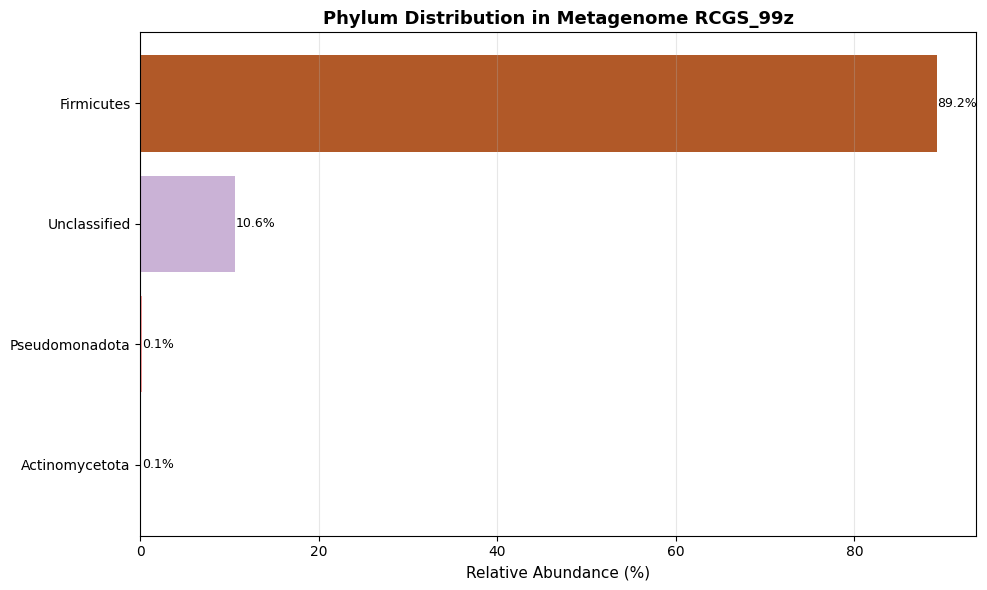


✅ График распределения по филумам сохранен: 'RCGS_99z_phylum_distribution.png'


In [ ]:
# анализ распределения по таксономическим уровням
print("Анализ распределения по таксономическим уровням (все таксоны)...")

def extract_taxonomic_level(taxon_path, level_prefix):
    """Извлекает таксон из определенного уровня"""
    if taxon_path == 'UNCLASSIFIED':
        return 'Unclassified'

    if '|' in str(taxon_path):
        parts = str(taxon_path).split('|')
        for part in parts:
            if part.startswith(level_prefix):
                if '__' in part:
                    _, name = part.split('__', 1)
                    return name.replace('_', ' ')
                return part
    return 'Unknown'

# уровни для анализа
levels = {
    'Phylum': 'p__',
    'Class': 'c__',
    'Order': 'o__',
    'Family': 'f__',
    'Genus': 'g__',
    'Species': 's__'
}

# создание таблицы для каждого уровня
level_data = {}

for level_name, prefix in levels.items():
    # добавение колонки с таксоном
    all_taxa[f'{level_name}_taxon'] = all_taxa['taxon_path'].apply(
        lambda x: extract_taxonomic_level(x, prefix))

    # группировка по уровню
    grouped = all_taxa.groupby(f'{level_name}_taxon')['abundance'].sum().reset_index()
    grouped = grouped.sort_values('abundance', ascending=False)
    level_data[level_name] = grouped

    print(f"\n{'='*50}")
    print(f"📊 {level_name.upper()} LEVEL (всего: {len(grouped)})")
    print(f"{'='*50}")
    print(f"{'Taxon':<35} {'Abundance':>10} {'%':>7}")
    print("-"*55)

    # выводим все таксоны на уровне
    for i, row in grouped.iterrows():
        if row['abundance'] > 0:
            taxon_name = row[f'{level_name}_taxon']
            abundance = row['abundance']
            if taxon_name == 'Unclassified':
                print(f"{taxon_name:<35} {abundance:>10.3f}%")
            else:
                print(f"  {taxon_name:<33} {abundance:>10.3f}%")

    # итоговая строка
    total = grouped['abundance'].sum()
    print("-"*55)
    print(f"{'TOTAL':<35} {total:>10.2f}%")

# создание визуализации для филумов
print("\nСоздание графика распределения по филумам...")

phylum_data = level_data['Phylum']

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(phylum_data)), phylum_data['abundance'][::-1],
                color=plt.cm.Paired(np.linspace(0, 1, len(phylum_data))))
plt.yticks(range(len(phylum_data)), phylum_data['Phylum_taxon'][::-1])
plt.xlabel('Relative Abundance (%)', fontsize=11)
plt.title('Phylum Distribution in Metagenome', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# добавление значений
for i, (bar, abundance) in enumerate(zip(bars, phylum_data['abundance'][::-1])):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{abundance:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()

# сохранение
phylum_filename = 'RCGS_99z_phylum_distribution.png'
plt.savefig(phylum_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ График распределения по филумам сохранен: '{phylum_filename}'")

Создание сравнительных графиков для всех уровней...


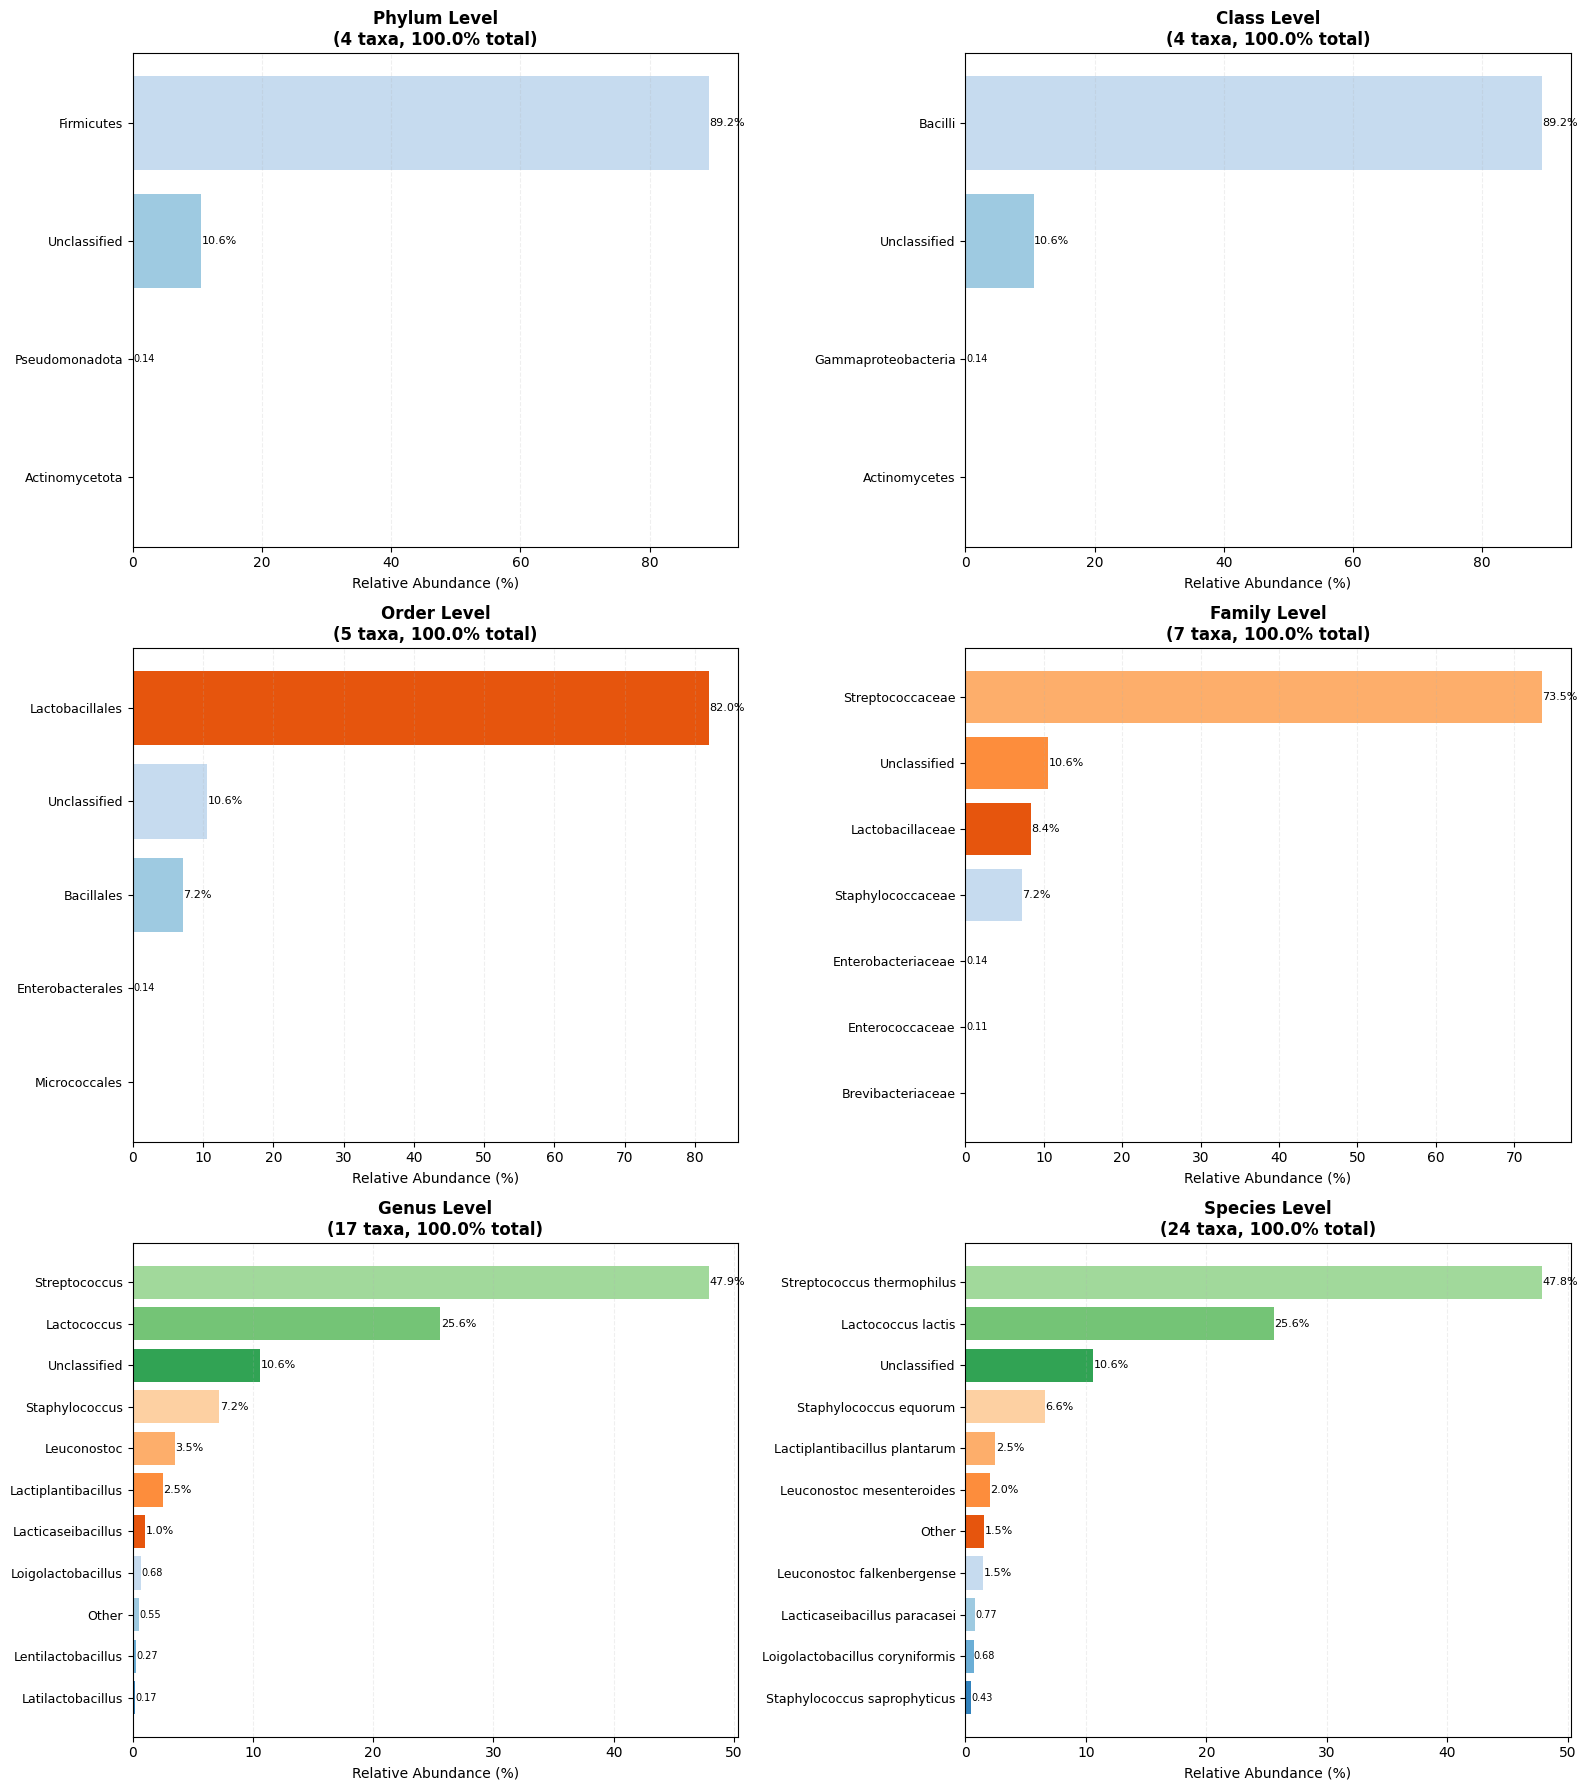


✅ Сравнительные графики сохранены: 'RCGS_99z_all_levels_comparison.png'
   Показаны все 6 таксономических уровней


In [ ]:
# создание сравнительных графиков для всех таксономических уровней
print("Создание сравнительных графиков для всех уровней...")

# создание6 субплoтов (для каждого уровня)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# цветовая схема
colors = plt.cm.tab20c(np.linspace(0, 1, 20))

# графики для каждого уровня
for idx, (level_name, ax) in enumerate(zip(['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species'], axes)):
    data = level_data[level_name]

    # ограничение для уровней с большим количеством таксонов
    if len(data) > 10 and level_name in ['Genus', 'Species']:
        # топ-10 + остальные как "Other"
        top_data = data.head(10).copy()
        other_sum = data.iloc[10:]['abundance'].sum()

        if other_sum > 0:
            other_row = pd.DataFrame({
                f'{level_name}_taxon': ['Other'],
                'abundance': [other_sum]
            })
            plot_data = pd.concat([top_data, other_row])
        else:
            plot_data = top_data
    else:
        plot_data = data

    # сортировка для отображения
    plot_data = plot_data.sort_values('abundance')

    # создание горизонтального барплота
    bars = ax.barh(range(len(plot_data)), plot_data['abundance'],
                   color=colors[:len(plot_data)])

    # Настройка осей
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(plot_data[f'{level_name}_taxon'], fontsize=9)
    ax.set_xlabel('Relative Abundance (%)', fontsize=10)
    ax.set_title(f'{level_name} Level\n({len(data)} taxa, {data["abundance"].sum():.1f}% total)',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.2, linestyle='--')

    # добавление значений
    for i, (bar, abundance) in enumerate(zip(bars, plot_data['abundance'])):
        if abundance >= 1:
            ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                   f'{abundance:.1f}%', ha='left', va='center', fontsize=8)
        elif abundance >= 0.1:
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                   f'{abundance:.2f}', ha='left', va='center', fontsize=7)

plt.tight_layout()

# сохранение
comparison_filename = 'RCGS_99z_all_levels_comparison.png'
plt.savefig(comparison_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Сравнительные графики сохранены: '{comparison_filename}'")
print("   Показаны все 6 таксономических уровней")

#### Анализ альфа-разнообразия

Расчет альфа-разнообразия для закваски сыра...

📊 Общее количество обработанных ридов: 2,148,879
📊 Сумма abundance всех таксонов: 100.00%

ИНДЕКСЫ АЛЬФА-РАЗНООБРАЗИЯ
1. Индекс Шеннона (Shannon H'): 1.547
2. Индекс Симпсона (Simpson λ): 0.3112
   Индекс разнообразия Симпсона (1-λ): 0.6888
3. Выравненность Пилу (Pielou's J'): 0.487
4. Индекс Chao1 (оценка богатства): 25.6
   Наблюдаемых видов: 24

ИНТЕРПРЕТАЦИЯ ДЛЯ ЗАКВАСКИ СЫРА

📊 ТЕКУЩИЕ ПОКАЗАТЕЛИ:
   • Индекс Шеннона = 1.547
   • Индекс Симпсона = 0.3112 (чем меньше, тем лучше)
   • Выравненность Пилу = 0.487
   • Видовое богатство (Chao1) = 25.6

🎯 ОЦЕНКА КАЧЕСТВА ЗАКВАСКИ:
   • Разнообразие: УМЕРЕННОЕ (оптимально для закваски)
   • Доминирование: УМЕРЕННОЕ (сбалансированное сообщество)
   • Равномерность: НИЗКАЯ (неравномерное распределение)

🔬 ИДЕАЛЬНЫЕ ПАРАМЕТРЫ ДЛЯ СЫРНОЙ ЗАКВАСКИ:
   • Индекс Шеннона: 1.5-2.0 (умеренное разнообразие)
   • Индекс Симпсона: 0.2-0.4 (небольшое доминирование)
   • Доминирующий вид: < 60% от общей ч

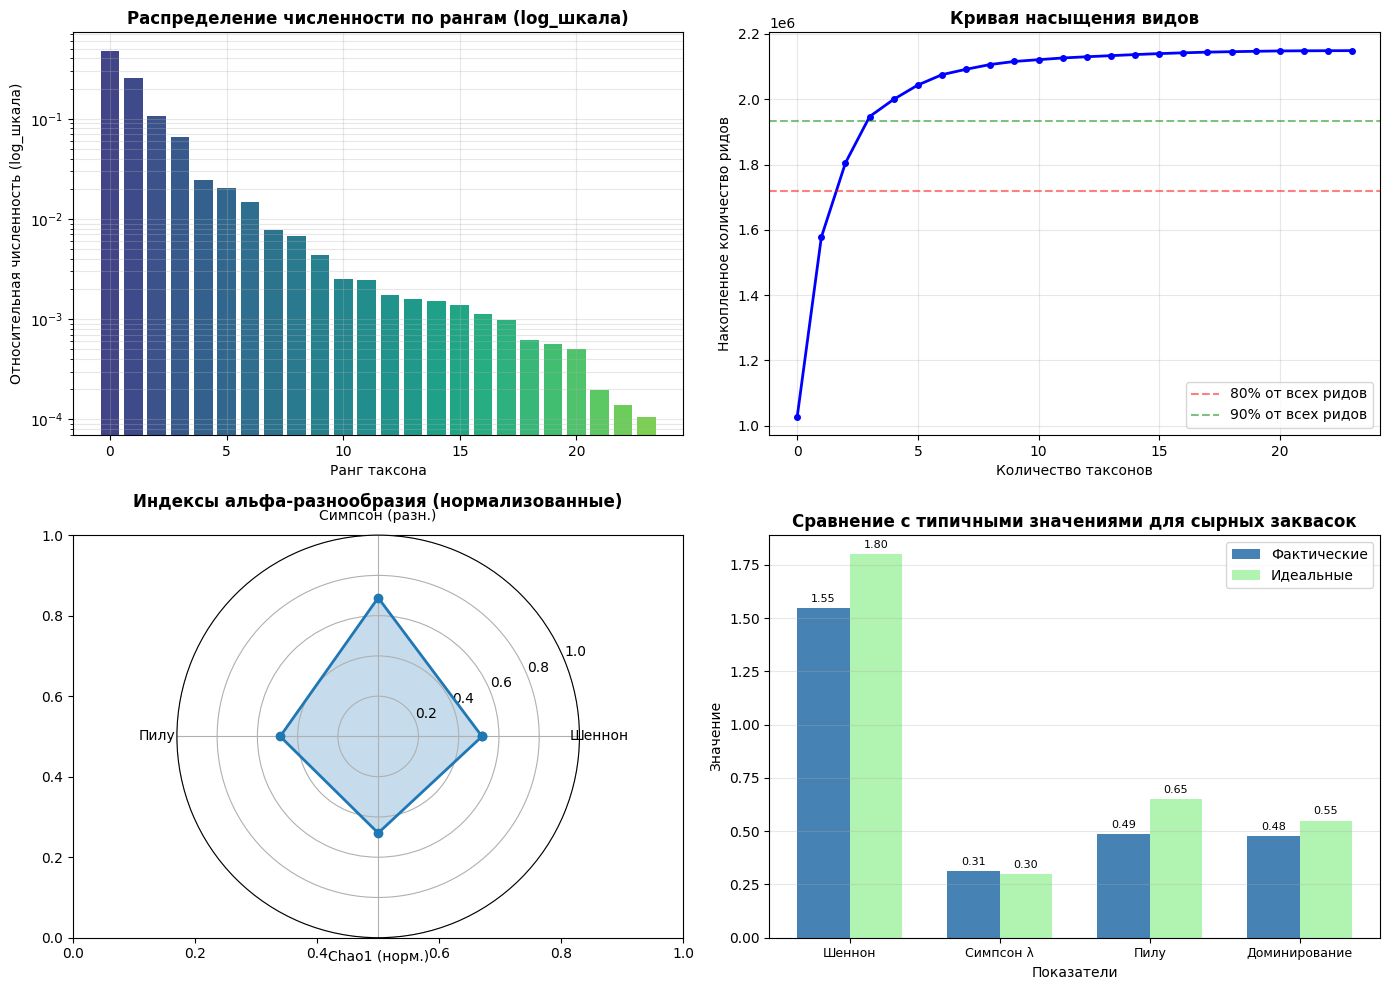


✅ Визуализация альфа-разнообразия сохранена: 'RCGS_99z_alpha_diversity_ru.png'
✅ Результаты альфа-разнообразия сохранены в JSON: 'RCGS_99z_alpha_diversity_ru.json'


In [ ]:
# расчет индексов альфа-разнообразия
import numpy as np
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

print("Расчет альфа-разнообразия для закваски сыра...")

# 1. подготовка данных
abundance_fractions = all_taxa['abundance'].values / 100.0

# общее количество ридов
total_reads = None
try:
    with open('RCGS_99z_full_profile.txt', 'r') as f:
        for line in f:
            if line.startswith('#') and 'reads processed' in line:
                total_reads = int(line.strip('#').strip().split()[0])
                break
    print(f"\n📊 Общее количество обработанных ридов: {total_reads:,}")
e
    total_abundance_pct = all_taxa['abundance'].sum()
    print(f"📊 Сумма abundance всех таксонов: {total_abundance_pct:.2f}%")

except:
    print("\n⚠️ Не удалось извлечь общее количество ридов, кривая будет в процентах")
    total_reads = None

# 2. расчет индексов
print("\n" + "="*60)
print("ИНДЕКСЫ АЛЬФА-РАЗНООБРАЗИЯ")
print("="*60)

# A. Shannon Index (H')
shannon_index = -np.sum(abundance_fractions * np.log(abundance_fractions))
print(f"1. Индекс Шеннона (Shannon H'): {shannon_index:.3f}")

# B. Simpson Index (λ)
simpson_index = np.sum(abundance_fractions ** 2)
print(f"2. Индекс Симпсона (Simpson λ): {simpson_index:.4f}")

# C. Simpson Diversity (1 - λ)
simpson_diversity = 1 - simpson_index
print(f"   Индекс разнообразия Симпсона (1-λ): {simpson_diversity:.4f}")

# D. Pielou's Evenness (J')
if len(abundance_fractions) > 1:
    pielou_evenness = shannon_index / np.log(len(abundance_fractions))
    print(f"3. Выравненность Пилу (Pielou's J'): {pielou_evenness:.3f}")
else:
    pielou_evenness = 0

# E. Chao1 Index (оценка богатства)
observed_species = len(abundance_fractions)
singleton = np.sum(abundance_fractions < 0.001)
doubleton = np.sum(abundance_fractions < 0.005)

if doubleton > 0:
    chao1_index = observed_species + (singleton**2) / (2 * doubleton)
else:
    chao1_index = observed_species + singleton * (singleton - 1) / 2

print(f"4. Индекс Chao1 (оценка богатства): {chao1_index:.1f}")
print(f"   Наблюдаемых видов: {observed_species}")

# 3. интерпретация для сырной закваски
print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ ДЛЯ ЗАКВАСКИ СЫРА")
print("="*60)

print("\n📊 ТЕКУЩИЕ ПОКАЗАТЕЛИ:")
print(f"   • Индекс Шеннона = {shannon_index:.3f}")
print(f"   • Индекс Симпсона = {simpson_index:.4f} (чем меньше, тем лучше)")
print(f"   • Выравненность Пилу = {pielou_evenness:.3f}")
print(f"   • Видовое богатство (Chao1) = {chao1_index:.1f}")

print("\n🎯 ОЦЕНКА КАЧЕСТВА ЗАКВАСКИ:")

if shannon_index < 1.0:
    print("   • Разнообразие: НИЗКОЕ (риск доминирования)")
elif shannon_index < 2.0:
    print("   • Разнообразие: УМЕРЕННОЕ (оптимально для закваски)")
else:
    print("   • Разнообразие: ВЫСОКОЕ (может быть нестабильным)")

if simpson_index > 0.5:
    print("   • Доминирование: ВЫСОКОЕ (один вид доминирует)")
elif simpson_index > 0.3:
    print("   • Доминирование: УМЕРЕННОЕ (сбалансированное сообщество)")
else:
    print("   • Доминирование: НИЗКОЕ (хорошо распределено)")

if pielou_evenness < 0.5:
    print("   • Равномерность: НИЗКАЯ (неравномерное распределение)")
elif pielou_evenness < 0.7:
    print("   • Равномерность: СРЕДНЯЯ (приемлемо для закваски)")
else:
    print("   • Равномерность: ВЫСОКАЯ (идеально сбалансировано)")

# 4. сравнение со средними значениями для заквасок
print("\n🔬 ИДЕАЛЬНЫЕ ПАРАМЕТРЫ ДЛЯ СЫРНОЙ ЗАКВАСКИ:")
print("   • Индекс Шеннона: 1.5-2.0 (умеренное разнообразие)")
print("   • Индекс Симпсона: 0.2-0.4 (небольшое доминирование)")
print("   • Доминирующий вид: < 60% от общей численности")
print("   • Второй вид: 20-40% (для стабильности)")

print("\n📈 ВАША ЗАКВАСКА:")
dominant_species = all_taxa.iloc[0]
second_species = all_taxa.iloc[1] if len(all_taxa) > 1 else None

print(f"   • Доминирующий вид: {dominant_species['short_name']} ({dominant_species['abundance']:.1f}%)")
if second_species is not None:
    second_name = second_species['short_name'] if 'short_name' in second_species else str(second_species['taxon_path'])[:50]
    print(f"   • Второй вид: {second_name} ({second_species['abundance']:.1f}%)")
    ratio = dominant_species['abundance'] / second_species['abundance']
    print(f"   • Соотношение 1-й/2-й: {ratio:.1f}:1")

# 5. визуализация
print("\nСоздание визуализации индексов...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# График 1: Распределение численности (log масштаб)
ax1 = axes[0]
sorted_abundance = np.sort(abundance_fractions)[::-1]
ax1.bar(range(len(sorted_abundance)), sorted_abundance,
        color=plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_abundance))))
ax1.set_yscale('log')
ax1.set_xlabel('Ранг таксона', fontsize=10)
ax1.set_ylabel('Относительная численность (log_шкала)', fontsize=10)
ax1.set_title('Распределение численности по рангам (log_шкала)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')

# График 2: Куммулятивная кривая (в абсолютных значениях или процентах)
ax2 = axes[1]
cumulative_pct = np.cumsum(sorted_abundance) * 100

# переменные для точек пересечения
n_80 = None
n_90 = None

if total_reads:
    # в абсолютных значениях
    cumulative_abs = cumulative_pct * total_reads / 100
    ax2.plot(range(len(cumulative_abs)), cumulative_abs, 'b-', linewidth=2, marker='o', markersize=4)
    ax2.axhline(y=total_reads * 0.8, color='r', linestyle='--', alpha=0.5, label='80% от всех ридов')
    ax2.axhline(y=total_reads * 0.9, color='g', linestyle='--', alpha=0.5, label='90% от всех ридов')
    ax2.set_ylabel('Накопленное количество ридов', fontsize=10)

    # точки пересечения
    try:
        n_80_idx = np.where(cumulative_abs >= total_reads * 0.8)[0]
        if len(n_80_idx) > 0:
            n_80 = n_80_idx[0] + 1
        else:
            n_80 = len(cumulative_abs)

        n_90_idx = np.where(cumulative_abs >= total_reads * 0.9)[0]
        if len(n_90_idx) > 0:
            n_90 = n_90_idx[0] + 1
        else:
            n_90 = len(cumulative_abs)

    except:
        n_80 = len(cumulative_abs)
        n_90 = len(cumulative_abs)

    print(f"\n📈 Кривая насыщения:")
    print(f"   • Для 80% всех ридов нужно: {n_80} таксонов из {len(cumulative_abs)}")
    print(f"   • Для 90% всех ридов нужно: {n_90} таксонов из {len(cumulative_abs)}")
    print(f"   • Максимальный накопленный процент: {cumulative_pct[-1]:.1f}%")
    print(f"   • Первые 3 таксона дают: {cumulative_pct[2]:.1f}% всех ридов")

else:
    # в процентах
    ax2.plot(range(len(cumulative_pct)), cumulative_pct, 'b-', linewidth=2, marker='o', markersize=4)
    ax2.axhline(y=80, color='r', linestyle='--', alpha=0.5, label='80%')
    ax2.axhline(y=90, color='g', linestyle='--', alpha=0.5, label='90%')
    ax2.set_ylabel('Накопленная численность (%)', fontsize=10)

    # точки пересечения для процентов
    try:
        n_80_idx = np.where(cumulative_pct >= 80)[0]
        if len(n_80_idx) > 0:
            n_80 = n_80_idx[0] + 1
        else:
            n_80 = len(cumulative_pct)

        n_90_idx = np.where(cumulative_pct >= 90)[0]
        if len(n_90_idx) > 0:
            n_90 = n_90_idx[0] + 1
        else:
            n_90 = len(cumulative_pct)
    except:
        n_80 = len(cumulative_pct)
        n_90 = len(cumulative_pct)

    print(f"\n📈 Кривая насыщения:")
    print(f"   • Для 80% нужно: {n_80} таксонов из {len(cumulative_pct)}")
    print(f"   • Для 90% нужно: {n_90} таксонов из {len(cumulative_pct)}")
    print(f"   • Максимальный накопленный процент: {cumulative_pct[-1]:.1f}%")
    print(f"   • Первые 3 таксона дают: {cumulative_pct[2]:.1f}%")

ax2.set_xlabel('Количество таксонов', fontsize=10)
ax2.set_title('Кривая насыщения видов', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: радарная диаграмма индексов
ax3 = axes[2]
indices = ['Шеннон', 'Симпсон (разн.)', 'Пилу', 'Chao1 (норм.)']
values = [
    min(shannon_index / 3.0, 1.0),  # нормализация к 0-1 (max Shannon ~3)
    simpson_diversity,  # Уже 0-1
    pielou_evenness,    # Уже 0-1
    min(observed_species / 50.0, 1.0)  # нормализация к 0-1
]

angles = np.linspace(0, 2 * np.pi, len(indices), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

ax3 = plt.subplot(2, 2, 3, polar=True)
ax3.plot(angles, values, 'o-', linewidth=2)
ax3.fill(angles, values, alpha=0.25)
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(indices, fontsize=10)
ax3.set_ylim(0, 1)
ax3.set_title('Индексы альфа-разнообразия (нормализованные)', fontsize=12, fontweight='bold', pad=20)
ax3.grid(True)

# График 4: Сравнение с идеальными значениями
ax4 = axes[3]
metrics = ['Шеннон', 'Симпсон λ', 'Пилу', 'Доминирование']
actual_values = [shannon_index, simpson_index, pielou_evenness, dominant_species['abundance']/100]
ideal_values = [1.8, 0.3, 0.65, 0.55]  # Идеальные для закваски

x = np.arange(len(metrics))
width = 0.35

bars1 = ax4.bar(x - width/2, actual_values, width, label='Фактические', color='steelblue')
bars2 = ax4.bar(x + width/2, ideal_values, width, label='Идеальные', color='lightgreen', alpha=0.7)

ax4.set_xlabel('Показатели', fontsize=10)
ax4.set_ylabel('Значение', fontsize=10)
ax4.set_title('Сравнение с типичными значениями для сырных заквасок', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, fontsize=9)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()

# Сохраняем
alpha_diversity_filename = 'RCGS_99z_alpha_diversity_ru.png'
plt.savefig(alpha_diversity_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Визуализация альфа-разнообразия сохранена: '{alpha_diversity_filename}'")

# 6. сохранение результатов в файл
alpha_results = {
    'Shannon_index': float(shannon_index),
    'Simpson_index': float(simpson_index),
    'Simpson_diversity': float(simpson_diversity),
    'Pielou_evenness': float(pielou_evenness),
    'Chao1_estimate': float(chao1_index),
    'Observed_species': int(observed_species),
    'Dominant_species': str(dominant_species['short_name']),
    'Dominant_abundance': float(dominant_species['abundance']),
    'Second_species': str(second_species['short_name']) if second_species is not None else 'None',
    'Second_abundance': float(second_species['abundance']) if second_species is not None else 0,
    'Total_reads': int(total_reads) if total_reads is not None else None,
    'Taxa_for_80_percent': int(n_80) if n_80 is not None else None,
    'Taxa_for_90_percent': int(n_90) if n_90 is not None else None,
    'Max_cumulative_percent': float(cumulative_pct[-1]) if len(cumulative_pct) > 0 else 0
}

import json
alpha_json_filename = 'RCGS_99z_alpha_diversity_ru.json'
with open(alpha_json_filename, 'w', encoding='utf-8') as f:
    json.dump(alpha_results, f, indent=4, ensure_ascii=False)

print(f"✅ Результаты альфа-разнообразия сохранены в JSON: '{alpha_json_filename}'")

In [ ]:
# сохранение на Google Drive
import shutil
import os

# создание папки для сохранения
save_dir = '/content/drive/MyDrive/ВКР/метагеном/results_metaphlan/'
os.makedirs(save_dir, exist_ok=True)

# список файлов для сохранения
important_files = [
    'RCGS_99z_full_profile.txt',           # основной профиль
    'RCGS_99z.map',                        # файл выравниваний
    'full_analysis.log',                   # лог выполнения
    'RCGS_99z_taxonomic_profile_table.csv', # таблица для документов
    'RCGS_99z_alpha_diversity.json',       # JSON с индексами
    # графики:
    'RCGS_99z_all_taxa.png',
    'RCGS_99z_top10_pie.png',
    'RCGS_99z_phylum_distribution.png',
    'RCGS_99z_all_levels_comparison.png',
    'RCGS_99z_alpha_diversity.png'
]

print("Копирование файлов на Google Drive...")
copied_count = 0

for file in important_files:
    if os.path.exists(file):
        shutil.copy(file, save_dir + file)
        print(f"✓ {file}")
        copied_count += 1
    else:
        print(f"✗ {file} (не найден, пропускаем)")

print(f"\n✅ Скопировано {copied_count} файлов в: {save_dir}")
print("\n📁 Содержимое папки результатов:")
!ls -la {save_dir} 2>/dev/null || echo "Папка создана"

Копирование файлов на Google Drive...
✓ RCGS_99z_full_profile.txt
✓ RCGS_99z.map
✓ full_analysis.log
✓ RCGS_99z_taxonomic_profile_table.csv
✓ RCGS_99z_alpha_diversity.json
✓ RCGS_99z_all_taxa.png
✓ RCGS_99z_top10_pie.png
✓ RCGS_99z_phylum_distribution.png
✓ RCGS_99z_all_levels_comparison.png
✓ RCGS_99z_alpha_diversity.png

✅ Скопировано 10 файлов в: /content/drive/MyDrive/ВКР/метагеном/results_metaphlan/

📁 Содержимое папки результатов:
total 281742
-rw------- 1 root root 276889001 Dec  7 19:24 full_analysis.log
-rw------- 1 root root    681632 Dec  7 19:24 RCGS_99z_all_levels_comparison.png
-rw------- 1 root root    500801 Dec  7 19:24 RCGS_99z_all_taxa.png
-rw------- 1 root root       412 Dec  7 19:24 RCGS_99z_alpha_diversity.json
-rw------- 1 root root    554397 Dec  7 19:24 RCGS_99z_alpha_diversity.png
-rw------- 1 root root      4431 Dec  7 19:24 RCGS_99z_full_profile.txt
-rw------- 1 root root   9315032 Dec  7 19:24 RCGS_99z.map
-rw------- 1 root root    113527 Dec  7 19:24 RCGS_